# ICA Experiment

In [1]:
import numpy as np
import os
import torch 
import torch.distributions as dists
from matplotlib import pyplot as plt
from scipy import stats
import sys
# Add parent directory of this file to path
sys.path.append(os.path.dirname(os.path.abspath('')))
from MSM.utils import data as utils
from MSM.utils.data import get_ci  # noqa: E402

data_path = os.path.join(os.path.pardir,"simulated_data", "NormalEstimation")

plt.rc('font',**{'family':'sans-serif'})
#If fonttype = 1 doesn't work with LaTeX, try fonttype 42.
plt.rc('pdf',fonttype = 42)
plt.rc('ps',fonttype = 42)
plt.rcParams['figure.dpi'] = 140


## 10 Dim Vary Miss

In [2]:
# Read in data
save_path = os.path.join(os.path.pardir,"simulated_data", "ICA","10Dim_StrongConnection","VaryMiss")
methods = ["iw", "em", "variational", "missdiff"]
names = ["Marg-IW (Ours)", "EM", "Marg-Var (Ours)", "Zeroed"]
miss_probs = torch.arange(0.2,0.71,0.1)
name_dict = dict(zip(methods, names))
theta_dists = {method: [] for method in methods}
losses = {method: [] for method in methods}
for method in ["iw", "em", "missdiff", "variational"]:
    temp_mean = []
    temp_true_mean = []
    temp_prec = []
    temp_true_cov = []
    # Get samples
    for miss_prob in miss_probs:
        data = torch.load(os.path.join(save_path,f"{method}_varymiss_p={miss_prob:.1f}.pt"),weights_only=True)
        temp_theta = utils.recursive_tensorize(data["Est Thetas"])
        temp_true_theta = utils.recursive_tensorize(data["True Thetas"])

        theta_dists[method].append(torch.linalg.matrix_norm(temp_theta-temp_true_theta, dim=(-1,-2), ord=2))
        losses[method].append(utils.recursive_tensorize(data["Losses"]))
    # Combine into tensors
    print(method)

iw
em
missdiff
variational


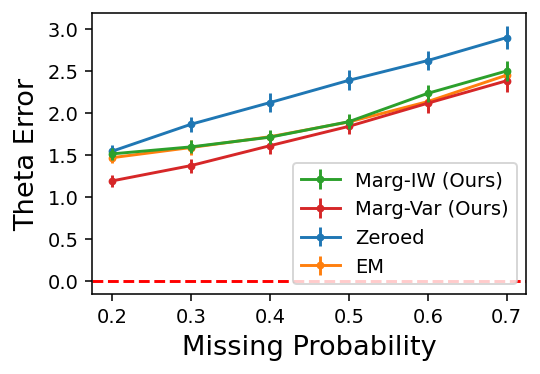

In [3]:
plot_errors = ["Mean Distance (L2)", "Precision Distance (Frobenius)","Fisher Divergence", "KL Divergence"]

plot_methods = ["iw", "variational", "missdiff", "em" ]
colours = ["C2", "C3","C0","C1", "C4"]
fig, ax = plt.subplots(figsize=(4, 2.6))
for i, method in enumerate(plot_methods):
    # Get confidence intervals
    temp_list = []
    for j in range(len(miss_probs)):
        data = theta_dists[method][j]
        plot_losses = losses[method][j]
        temp_list.append(get_ci(data, dim=-1).detach().clone())
        # temp_list.append(torch.nanquantile(data, torch.tensor([0.5,0.25,0.75]), dim=-1))
    dist_cis = torch.stack(temp_list, dim=-1)
    ax.errorbar(miss_probs, dist_cis[0], yerr=dist_cis[0]-dist_cis[1],
                label=name_dict[method], fmt="-o",alpha=1, markersize=3, color=colours[i], zorder=5-i)
ax.legend()
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Missing Probability", fontsize=14)
ax.set_ylabel("Theta Error", fontsize=14)
fig.savefig(f"../plots/ICA/ICA_thetaerror_strongconnection_varymiss.pdf", bbox_inches="tight")

## 10 Dim Vary Sample Size

In [4]:
# Read in data
save_path = os.path.join(os.path.pardir,"simulated_data", "ICA","10Dim_StrongConnection","VarySampleSize")
methods = ["iw", "em", "variational", "missdiff"]
names = ["Marg-IW (Ours)", "EM", "Marg-Var (Ours)", "Zeroed"]
# sample_sizes = [200,500,1000,2000,5000]
sample_sizes = [400, 600, 800, 1000, 1200, 1400]

name_dict = dict(zip(methods, names))
theta_dists = {method: [] for method in methods}
losses = {method: [] for method in methods}
for method in methods:
    temp_mean = []
    temp_true_mean = []
    temp_prec = []
    temp_true_cov = []
    # Get samples
    for sample_size in sample_sizes:
        data = torch.load(os.path.join(save_path,f"{method}_varyn_n={sample_size}.pt"),weights_only=True)
        temp_theta = utils.recursive_tensorize(data["Est Thetas"])
        temp_true_theta = utils.recursive_tensorize(data["True Thetas"])

        theta_dists[method].append(torch.linalg.matrix_norm(temp_theta-temp_true_theta, dim=(-1,-2), ord=2))
        losses[method].append(utils.recursive_tensorize(data["Losses"]))
    # Combine into tensors
    print(method)

iw
em
variational
missdiff


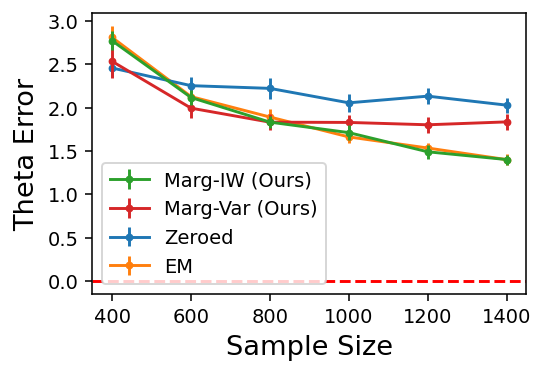

In [5]:
plot_errors = ["Mean Distance (L2)", "Precision Distance (Frobenius)","Fisher Divergence", "KL Divergence"]

plot_methods = ["iw", "variational", "missdiff", "em" ]
colours = ["C2", "C3","C0","C1", "C4"]

fig, ax = plt.subplots(figsize=(4, 2.6))
for i, method in enumerate(plot_methods):
    # Get confidence intervals
    temp_list = []
    for j in range(len(sample_sizes)):
        data = theta_dists[method][j]
        plot_losses = losses[method][j]
        temp_list.append(get_ci(data, dim=-1).detach().clone())
        # temp_list.append(torch.nanquantile(data, torch.tensor([0.5,0.25,0.75]), dim=-1).detach().clone())
    dist_cis = torch.stack(temp_list, dim=-1)
    ax.errorbar(sample_sizes, dist_cis[0], yerr=dist_cis[0]-dist_cis[1],
                label=name_dict[method], fmt="-o",alpha=1, markersize=3, color=colours[i], zorder=5-i)
ax.legend()
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Sample Size", fontsize=14)
ax.set_ylabel("Theta Error", fontsize=14)
fig.savefig(f"../plots/ICA/ICA_thetaerror_strongconnection_varyn.pdf", bbox_inches="tight")

## Vary Dimension

In [6]:
# Read in data
save_path = os.path.join(os.path.pardir,"simulated_data", "ICA","10Dim_StrongConnection","VaryDim")
methods = ["iw", "em", "variational_klnew", "missdiff"]
names = ["Marg-IW (Ours)", "EM", "Marg-Var (Ours)", "Zeroed"]
# sample_sizes = [200,500,1000,2000,5000]
dims = [10, 20, 30, 40, 50]

name_dict = dict(zip(methods, names))
theta_dists = {method: [] for method in methods}
losses = {method: [] for method in methods}
for method in methods:
    temp_mean = []
    temp_true_mean = []
    temp_prec = []
    temp_true_cov = []
    # Get samples
    for dim in dims:
        data = torch.load(os.path.join(save_path,f"{method}_varydim_d={dim}.pt"),weights_only=True)
        temp_theta = utils.recursive_tensorize(data["Est Thetas"])
        temp_true_theta = utils.recursive_tensorize(data["True Thetas"])

        theta_dists[method].append(torch.linalg.matrix_norm(temp_theta-temp_true_theta, dim=(-1,-2), ord=2))
        losses[method].append(utils.recursive_tensorize(data["Losses"]))
    # Combine into tensors
    print(method)

iw
em
variational_klnew
missdiff


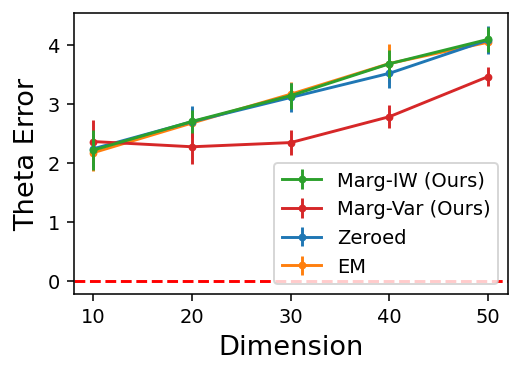

In [7]:
plot_errors = ["Mean Distance (L2)", "Precision Distance (Frobenius)","Fisher Divergence", "KL Divergence"]

plot_methods = ["iw", "variational_klnew", "missdiff", "em" ]
colours = ["C2", "C3","C0","C1", "C4"]

fig, ax = plt.subplots(figsize=(4, 2.6))
for i, method in enumerate(plot_methods):
    # Get confidence intervals
    temp_list = []
    for j in range(len(dims)):
        data = theta_dists[method][j]
        plot_losses = losses[method][j]
        # temp_list.append(get_ci(data, dim=-1).detach().clone())
        temp_list.append(torch.nanquantile(data, torch.tensor([0.5,0.25,0.75]), dim=-1).detach().clone())
    dist_cis = torch.stack(temp_list, dim=-1)
    ax.errorbar(dims, dist_cis[0], yerr=dist_cis[0]-dist_cis[1],
                label=name_dict[method], fmt="-o",alpha=1, markersize=3, color=colours[i], zorder=5-i)
ax.legend(loc="lower right")
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Dimension", fontsize=14)
ax.set_ylabel("Theta Error", fontsize=14)
fig.savefig(f"../plots/ICA/ICA_thetaerror_strongconnection_varydim.pdf", bbox_inches="tight")

## Combined Plot

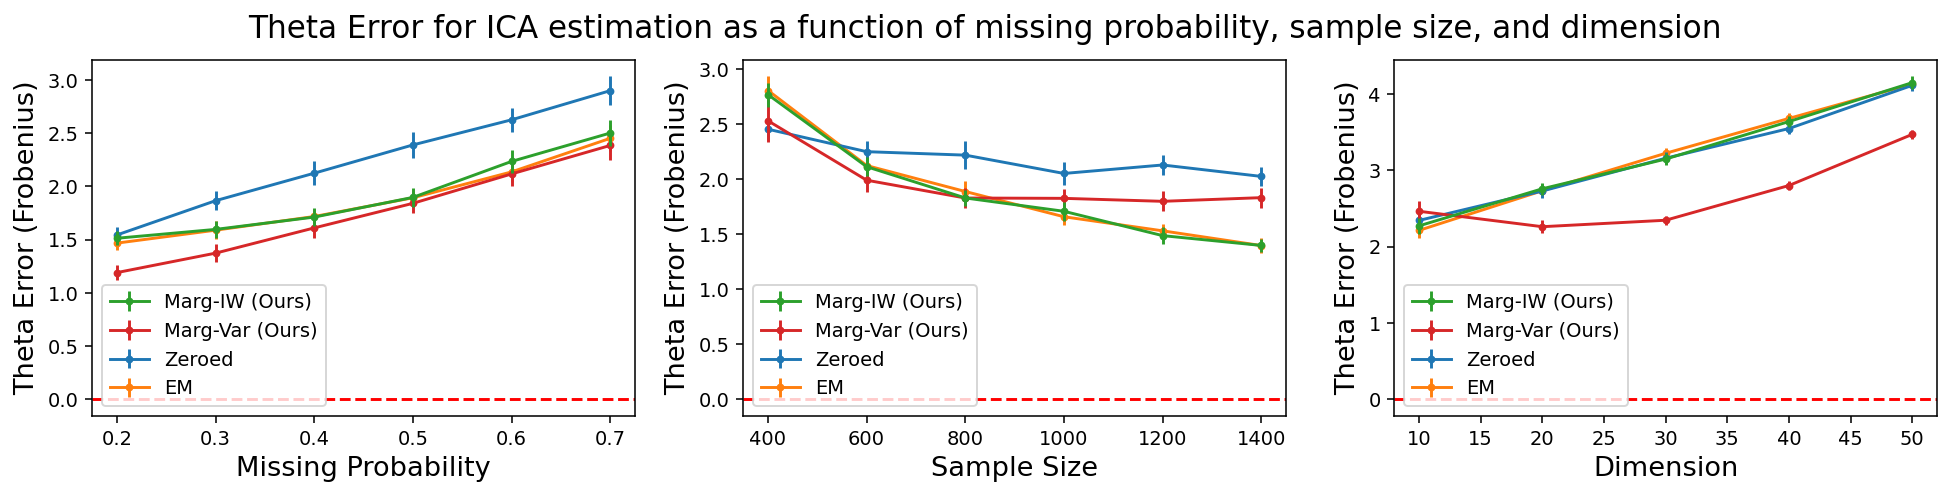

In [8]:

fig, ax = plt.subplots(figsize=(17, 3.3), ncols=3)
colours = ["C2", "C3","C0","C1", "C4"]
names = ["Marg-IW (Ours)", "EM", "Marg-Var (Ours)", "Zeroed"]
### Plot 1 ###
# Read in data
save_path = os.path.join(os.path.pardir,"simulated_data", "ICA","10Dim_StrongConnection","VaryMiss")
methods = ["iw", "em", "variational", "missdiff"]
miss_probs = torch.arange(0.2,0.71,0.1)
name_dict = dict(zip(methods, names))
theta_dists = {method: [] for method in methods}
losses = {method: [] for method in methods}
for method in ["iw", "em", "missdiff", "variational"]:
    temp_mean = []
    temp_true_mean = []
    temp_prec = []
    temp_true_cov = []
    # Get samples
    for miss_prob in miss_probs:
        data = torch.load(os.path.join(save_path,f"{method}_varymiss_p={miss_prob:.1f}.pt"),weights_only=True)
        temp_theta = utils.recursive_tensorize(data["Est Thetas"])
        temp_true_theta = utils.recursive_tensorize(data["True Thetas"])

        theta_dists[method].append(torch.linalg.matrix_norm(temp_theta-temp_true_theta, dim=(-1,-2), ord=2))
        losses[method].append(utils.recursive_tensorize(data["Losses"]))
    

# plot data
plot_methods = ["iw", "variational", "missdiff", "em" ]
for i, method in enumerate(plot_methods):
    # Get confidence intervals
    temp_list = []
    for j in range(len(miss_probs)):
        data = theta_dists[method][j]
        plot_losses = losses[method][j]
        temp_list.append(get_ci(data, dim=-1).detach().clone())
        # temp_list.append(torch.nanquantile(data, torch.tensor([0.5,0.25,0.75]), dim=-1))
    dist_cis = torch.stack(temp_list, dim=-1)
    ax[0].errorbar(miss_probs, dist_cis[0], yerr=dist_cis[0]-dist_cis[1],
                label=name_dict[method], fmt="-o",alpha=1, markersize=3, color=colours[i], zorder=5-i)
ax[0].legend()
ax[0].axhline(0, color="red", linestyle="--")
ax[0].set_xlabel("Missing Probability", fontsize=14)
ax[0].set_ylabel("Theta Error (Frobenius)", fontsize=14)

#### Plot 2 ####
# Read in data
save_path = os.path.join(os.path.pardir,"simulated_data", "ICA","10Dim_StrongConnection","VarySampleSize")
methods = ["iw", "em", "variational", "missdiff"]
# sample_sizes = [200,500,1000,2000,5000]
sample_sizes = [400, 600, 800, 1000, 1200, 1400]

name_dict = dict(zip(methods, names))
theta_dists = {method: [] for method in methods}
losses = {method: [] for method in methods}
for method in methods:
    temp_mean = []
    temp_true_mean = []
    temp_prec = []
    temp_true_cov = []
    # Get samples
    for sample_size in sample_sizes:
        data = torch.load(os.path.join(save_path,f"{method}_varyn_n={sample_size}.pt"),weights_only=True)
        temp_theta = utils.recursive_tensorize(data["Est Thetas"])
        temp_true_theta = utils.recursive_tensorize(data["True Thetas"])

        theta_dists[method].append(torch.linalg.matrix_norm(temp_theta-temp_true_theta, dim=(-1,-2), ord=2))
        losses[method].append(utils.recursive_tensorize(data["Losses"]))
    # Combine into tensors


plot_methods = ["iw", "variational", "missdiff", "em" ]
for i, method in enumerate(plot_methods):
    # Get confidence intervals
    temp_list = []
    for j in range(len(sample_sizes)):
        data = theta_dists[method][j]
        plot_losses = losses[method][j]
        temp_list.append(get_ci(data, dim=-1).detach().clone())
        # temp_list.append(torch.nanquantile(data, torch.tensor([0.5,0.25,0.75]), dim=-1).detach().clone())
    dist_cis = torch.stack(temp_list, dim=-1)
    ax[1].errorbar(sample_sizes, dist_cis[0], yerr=dist_cis[0]-dist_cis[1],
                label=name_dict[method], fmt="-o",alpha=1, markersize=3, color=colours[i], zorder=5-i)
ax[1].legend()
ax[1].axhline(0, color="red", linestyle="--")
ax[1].set_xlabel("Sample Size", fontsize=14)
ax[1].set_ylabel("Theta Error (Frobenius)", fontsize=14)

#### Plot 3 ####
# Read in data
save_path = os.path.join(os.path.pardir,"simulated_data", "ICA","10Dim_StrongConnection","VaryDim")
methods = ["iw", "em", "variational_klnew", "missdiff"]
dims = [10, 20, 30, 40, 50]

name_dict = dict(zip(methods, names))
theta_dists = {method: [] for method in methods}
losses = {method: [] for method in methods}
for method in methods:
    temp_mean = []
    temp_true_mean = []
    temp_prec = []
    temp_true_cov = []
    # Get samples
    for dim in dims:
        data = torch.load(os.path.join(save_path,f"{method}_varydim_d={dim}.pt"),weights_only=True)
        temp_theta = utils.recursive_tensorize(data["Est Thetas"])
        temp_true_theta = utils.recursive_tensorize(data["True Thetas"])

        theta_dists[method].append(torch.linalg.matrix_norm(temp_theta-temp_true_theta, dim=(-1,-2), ord=2))
        losses[method].append(utils.recursive_tensorize(data["Losses"]))
    # Combine into tensors

plot_methods = ["iw", "variational_klnew", "missdiff", "em" ]
for i, method in enumerate(plot_methods):
    # Get confidence intervals
    temp_list = []
    for j in range(len(dims)):
        data = theta_dists[method][j]
        plot_losses = losses[method][j]
        temp_list.append(get_ci(data, dim=-1).detach().clone())
        # temp_list.append(torch.nanquantile(data, torch.tensor([0.5,0.25,0.75]), dim=-1).detach().clone())
    dist_cis = torch.stack(temp_list, dim=-1)
    ax[2].errorbar(dims, dist_cis[0], yerr=dist_cis[0]-dist_cis[1],
                label=name_dict[method], fmt="-o",alpha=1, markersize=3, color=colours[i], zorder=5-i)
ax[2].legend()
ax[2].axhline(0, color="red", linestyle="--")
ax[2].set_xlabel("Dimension", fontsize=14)
ax[2].set_ylabel("Theta Error (Frobenius)", fontsize=14)
fig.suptitle("Theta Error for ICA estimation as a function of missing probability, sample size, and dimension", fontsize=16)
fig.savefig(f"../plots/ICA/ICA_thetaerror_strongconnection_multiplot.pdf", bbox_inches="tight")
